In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
df = pd.read_csv("../data/processed/superstore_clean.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,shipping_days,order_year,order_month,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10,0.1125


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (9994, 25)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub_category  

In [5]:
df[["sales", "profit", "discount", "profit_margin", "shipping_days"]].describe()

,sales,profit,discount,profit_margin,shipping_days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,0.120314,3.958175
std,623.245101,234.260108,0.206452,0.466754,1.747567
min,0.444000,-6599.978000,0.000000,-2.750000,0.000000
25%,17.280000,1.728750,0.000000,0.075000,3.000000
50%,54.490000,8.666500,0.200000,0.270000,4.000000
75%,209.940000,29.364000,0.200000,0.362500,5.000000
max,22638.480000,8399.976000,0.800000,0.500000,7.000000


                       sales       profit
category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


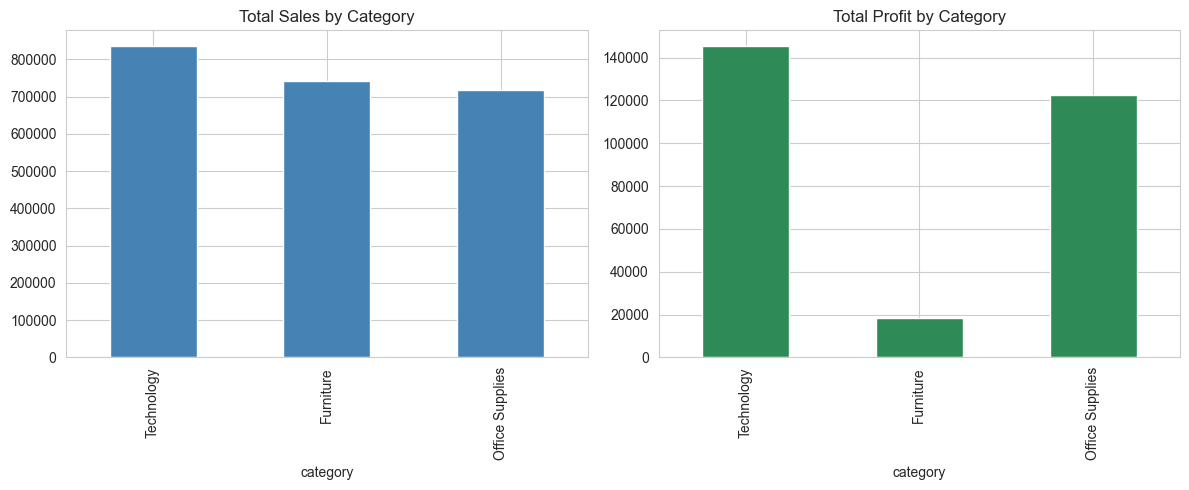

In [6]:
cat_summary = df.groupby("category")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
print(cat_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cat_summary["sales"].plot(kind="bar", ax=axes[0], color="steelblue", title="Total Sales by Category")
cat_summary["profit"].plot(kind="bar", ax=axes[1], color="seagreen", title="Total Profit by Category")
plt.tight_layout()
plt.show()

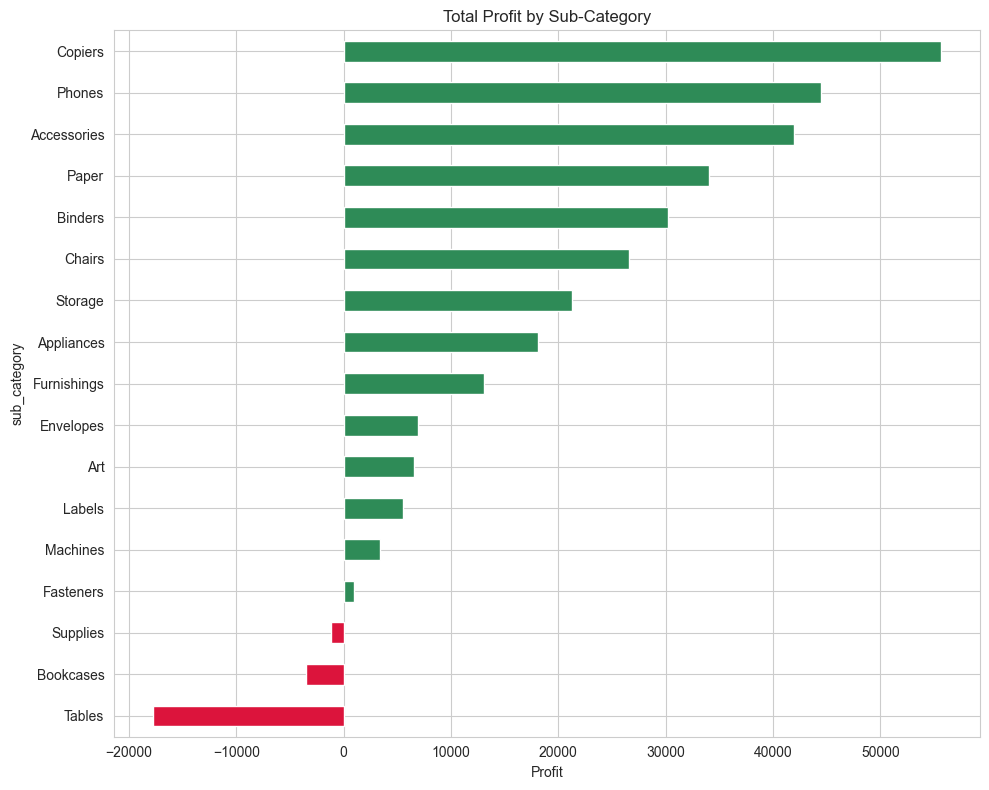

In [7]:
subcat_summary = df.groupby("sub_category")[["sales", "profit"]].sum().sort_values("profit")

plt.figure(figsize=(10, 8))
subcat_summary["profit"].plot(kind="barh", color=subcat_summary["profit"].apply(lambda x: "crimson" if x < 0 else "seagreen"))
plt.title("Total Profit by Sub-Category")
plt.xlabel("Profit")
plt.tight_layout()
plt.show()

               sales       profit
region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


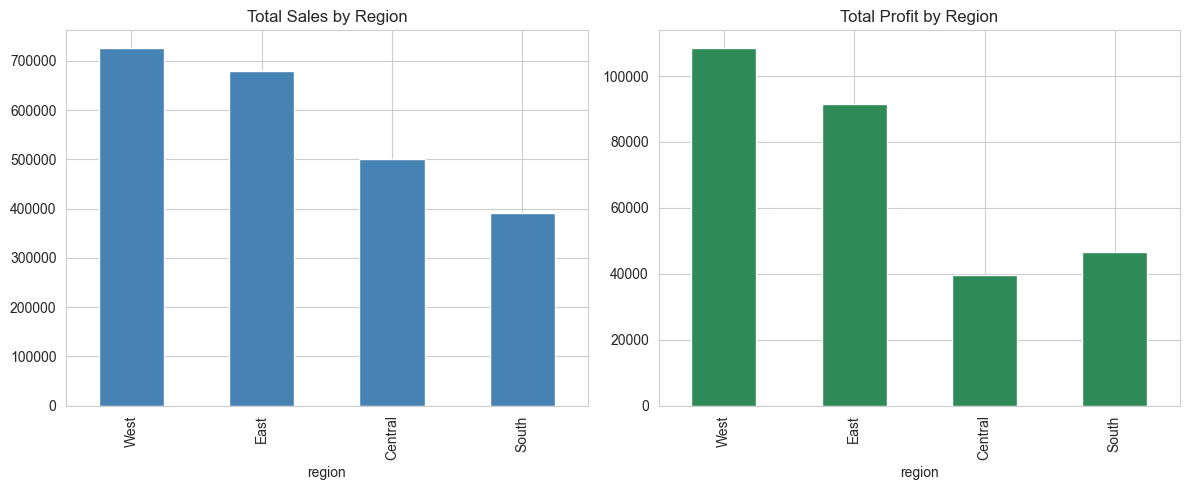

In [8]:
region_summary = df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
print(region_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
region_summary["sales"].plot(kind="bar", ax=axes[0], color="steelblue", title="Total Sales by Region")
region_summary["profit"].plot(kind="bar", ax=axes[1], color="seagreen", title="Total Profit by Region")
plt.tight_layout()
plt.show()

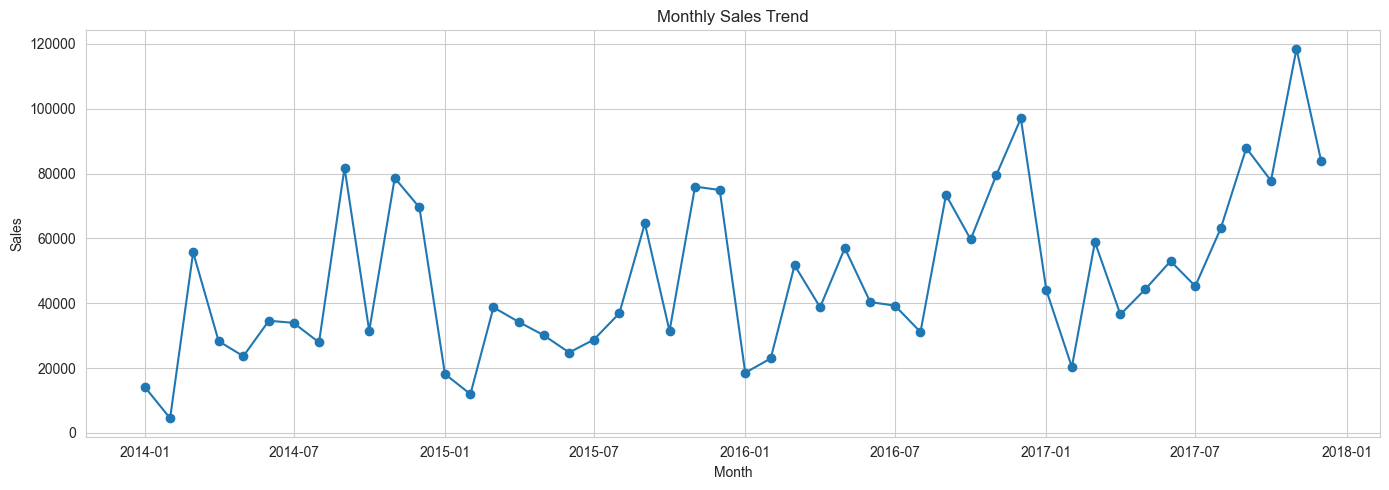

In [9]:
trend = df.groupby(["order_year", "order_month"])["sales"].sum().reset_index()
trend["period"] = pd.to_datetime(trend["order_year"].astype(str) + "-" + trend["order_month"].astype(str))

plt.figure(figsize=(14, 5))
plt.plot(trend["period"], trend["sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

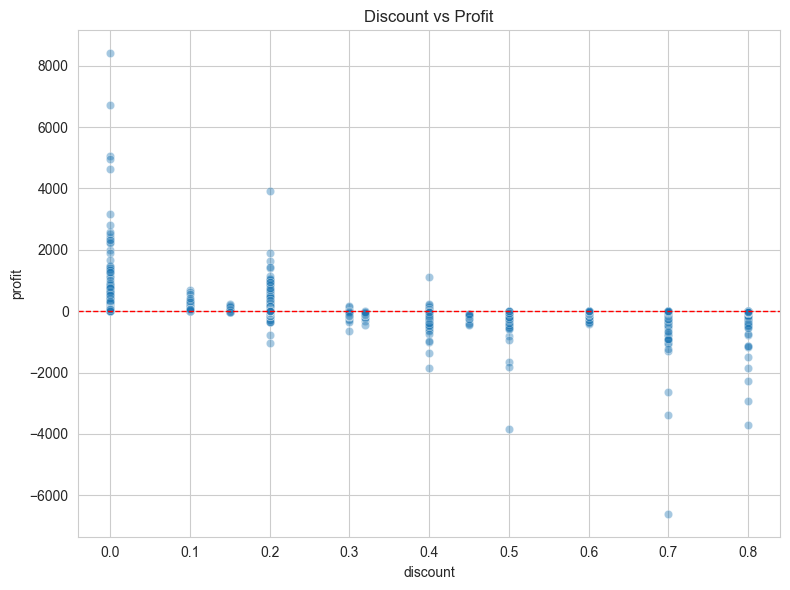

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="discount", y="profit", alpha=0.4)
plt.title("Discount vs Profit")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

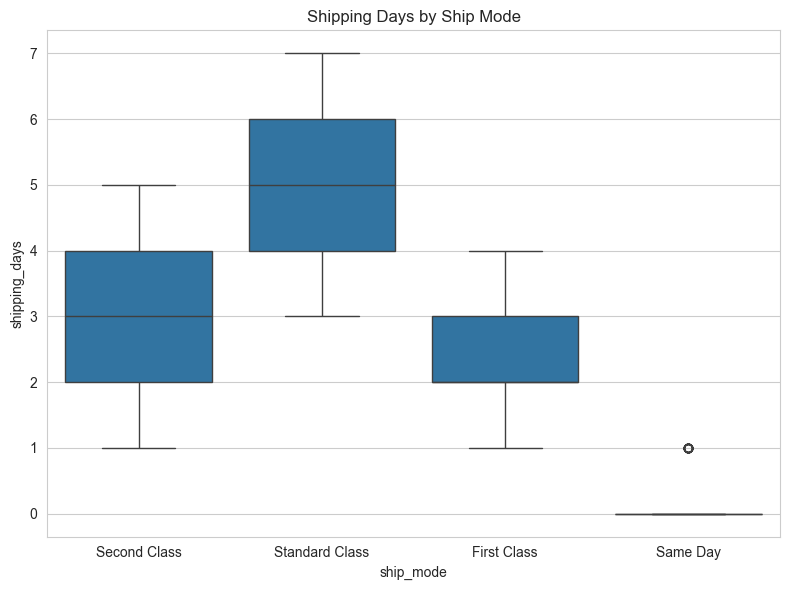

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="ship_mode", y="shipping_days")
plt.title("Shipping Days by Ship Mode")
plt.tight_layout()
plt.show()

In [16]:
product_summary = df.groupby("product_name")[["sales", "profit"]].sum()

top10_profit = product_summary.sort_values("profit", ascending=False).head(10)
bottom10_profit = product_summary.sort_values("profit").head(10)

print("Top 10 most profitable products:")
print(top10_profit)
print("\nBottom 10 least profitable (biggest losses):")
print(bottom10_profit)

Top 10 most profitable products:
                                                        sales      profit
product_name                                                             
Canon imageCLASS 2200 Advanced Copier               61599.824  25199.9280
Fellowes PB500 Electric Punch Plastic Comb Bind...  27453.384   7753.0390
Hewlett Packard LaserJet 3310 Copier                18839.686   6983.8836
Canon PC1060 Personal Laser Copier                  11619.834   4570.9347
HP Designjet T520 Inkjet Large Format Printer -...  18374.895   4094.9766
Ativa V4110MDD Micro-Cut Shredder                    7699.890   3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta    14299.890   3717.9714
Plantronics Savi W720 Multi-Device Wireless Hea...   9367.290   3696.2820
Ibico EPK-21 Electric Binding System                15875.916   3345.2823
Zebra ZM400 Thermal Label Printer                    6965.700   3343.5360

Bottom 10 least profitable (biggest losses):
                                 

In [18]:
biggest_losses = df.sort_values("profit").head(10)[
    ["order_id", "product_name", "category", "sales", "discount", "profit", "profit_margin"]
]
biggest_losses

,order_id,product_name,category,sales,discount,profit,profit_margin
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,0.7,-6599.9780,-1.466667
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,0.5,-3839.9904,-0.480000
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,0.8,-3701.8928,-1.700000
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,0.7,-3399.9800,-1.333333
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,0.8,-2929.4845,-1.550000
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Technology,1799.994,0.7,-2639.9912,-1.466667
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,0.8,-2287.7820,-1.500000
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4297.644,0.4,-1862.3124,-0.433333
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,0.8,-1850.9464,-1.700000
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,0.5,-1811.0784,-0.080000


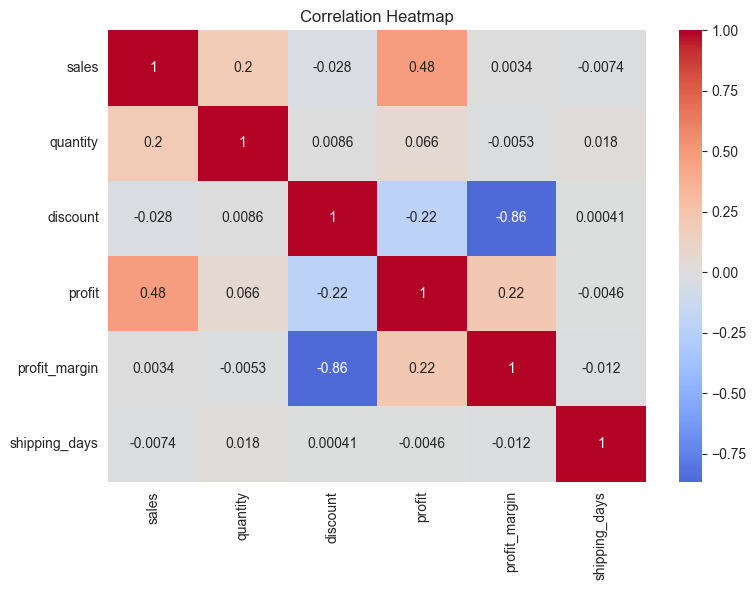

In [19]:
numeric_cols = ["sales", "quantity", "discount", "profit", "profit_margin", "shipping_days"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## EDA Summary — Key Findings

- **Sales leaders:** [Category] drives the highest total sales (~$[X]), followed by [Category].
- **Profit vs. sales mismatch:** [Category/Sub-Category] has strong sales but low/negative profit — likely driven by heavy discounting.
- **Loss-making sub-categories:** [Sub-Category names] show negative total profit, making them candidates for pricing or discount policy review.
- **Discount impact:** Profit drops sharply as discount increases beyond ~[X]%, with most losses concentrated above that threshold (see Discount vs Profit scatter).
- **Regional performance:** [Region] leads in both sales and profit; [Region] lags behind despite comparable sales.
- **Seasonality:** Sales peak in [Month(s)], likely tied to [holiday season / Q4], with a dip around [Month(s)].
- **Shipping:** [Ship Mode] has the widest spread in shipping days; [Ship Mode] is most consistent.
- **Correlation:** Discount and profit show a [strong/moderate] negative correlation (~[value]), while sales and quantity are [weakly/strongly] correlated (~[value]).

**Implication for the business:** [1–2 sentence takeaway, e.g. "Reducing discounts on Tables and Bookcases specifically could recover a meaningful share of lost profit without materially hurting sales volume."]